In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from astropy.coordinates import SkyCoord
import astropy.units as u
from pathlib import Path
from astropy.table import Table
from astropy.io import fits
import glob 
import re
from astropy.coordinates import angular_separation as ang

plt.style.use(['science','notebook','grid'])

In [42]:
JLA = pd.read_csv('/user/animesh.sah/DES_analysis/jla.txt', delim_whitespace=True,  header=0)
JLA_Coords = SkyCoord(JLA['ra'], JLA['dec'], unit=(u.degree, u.degree))
JLA['l'] = JLA_Coords.galactic.l.degree
JLA['b'] = JLA_Coords.galactic.b.degree

/tmp/ipykernel_1470907/2932413378.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  JLA = pd.read_csv('/user/animesh.sah/DES_analysis/jla.txt', delim_whitespace=True,  header=0)


In [43]:
url ='/user/animesh.sah/DES_analysis/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_Metadata.csv'
des_meta = pd.read_csv(url,sep='\s+',comment='#',header=0)

des_hd = pd.read_csv('/user/animesh.sah/DES_analysis/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv',sep='\s+',comment='#',header=0)
url='https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat'
pplus= pd.read_csv(url, delim_whitespace=True)

/tmp/ipykernel_1470907/3033549939.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pplus= pd.read_csv(url, delim_whitespace=True)


In [4]:
##crossmatch ra and dec with the data files
lc_file_path = Path('/user/animesh.sah/DES_analysis/DES-SN5YR//0_DATA')
lc_files = sorted(lc_file_path.rglob('*HEAD.FITS.gz'))

dfs = []
for file in lc_files:
    print(f'\nOpening: {file.name}')
    with fits.open(file) as hdul:
        data = Table(hdul[1].data).to_pandas()
        data = data[['SNID', 'RA', 'DEC','REDSHIFT_HELIO']].copy()
        dfs.append(data)
DES_lc_head = pd.concat(dfs, ignore_index=True)
DES_lc_head['SNID'] = DES_lc_head['SNID'].astype(str).str.strip()
des_meta['CID'] = des_meta['CID'].astype(str).str.strip()
merged = des_meta.merge(DES_lc_head, left_on='CID', right_on='SNID', how='left')
dz = np.abs(
    merged['zHEL'] - merged['REDSHIFT_HELIO']
)
bad = merged[dz > 1e-5]

print(f'Mismatches: {len(bad)}')
des_m = merged

des5yr_coords = SkyCoord(ra=des_m['RA'].values * u.deg,
                        dec=des_m['DEC'].values * u.deg,
                        frame='icrs')
des_m['l'] = des5yr_coords.galactic.l.wrap_at(180 * u.deg).deg
des_m['b'] = des5yr_coords.galactic.b.deg


Opening: DES-SN5YR_DES_HEAD.FITS.gz

Opening: DES-SN5YR_Foundation_HEAD.FITS.gz

Opening: DES-SN5YR_LOWZ_HEAD.FITS.gz
Mismatches: 0


(array([  8.,  12.,   9., 592.,   6.,   6.,   4.,   1.,   2.,   4., 102.,
        188.,   4.,   5.,   3.,   5.,   2.,   5.,   1.,  10.,  17.,  12.,
          8.,   5.,   8.,   6.,  14.,   9.,   7., 765.]),
 array([-179.86519246, -167.90372799, -155.94226353, -143.98079906,
        -132.0193346 , -120.05787014, -108.09640567,  -96.13494121,
         -84.17347675,  -72.21201228,  -60.25054782,  -48.28908336,
         -36.32761889,  -24.36615443,  -12.40468996,   -0.4432255 ,
          11.51823896,   23.47970343,   35.44116789,   47.40263235,
          59.36409682,   71.32556128,   83.28702574,   95.24849021,
         107.20995467,  119.17141914,  131.1328836 ,  143.09434806,
         155.05581253,  167.01727699,  178.97874145]),
 <BarContainer object of 30 artists>)

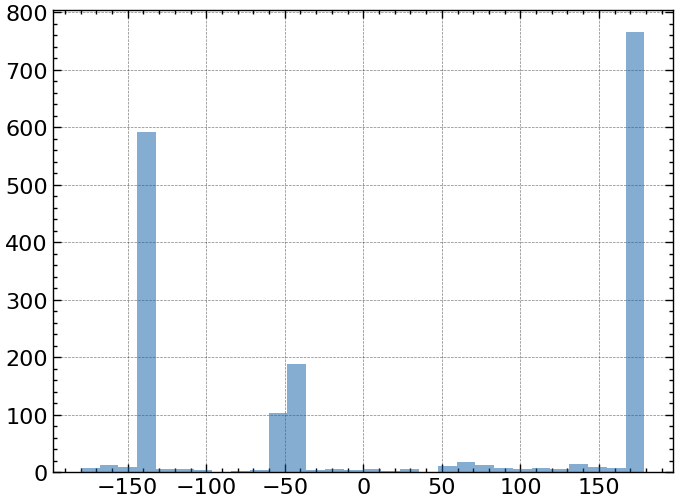

In [5]:
plt.hist(des_m['l'], bins=30, alpha=0.5, label='DES 5YR')

In [6]:

for df in (des_meta, des_hd, pplus):
    df['CID'] = df['CID'].astype(str).str.strip()

def report(df, name):
    n = len(df)
    nun = df['CID'].nunique()
    dups = df['CID'][df['CID'].duplicated(keep=False)].unique()
    print(f"{name}: rows={n}, unique_CIDs={nun}, n_dup_CIDs={len(dups)}")
    if len(dups):
        print("  dup examples:", dups[:10])

report(des_hd, 'des_hd')
report(des_meta, 'des_meta')
report(pplus, 'pplus')

s_hd = set(des_hd['CID'])
s_meta = set(des_meta['CID'])
s_pplus = set(pplus['CID'])

print("des_hd - des_meta (examples):", list(s_hd - s_meta)[:10])
print("des_meta - des_hd (examples):", list(s_meta - s_hd)[:10])
print("des_hd - pplus (examples):", list(s_hd - s_pplus)[:10])
print("pplus - des_hd (examples):", list(s_pplus - s_hd)[:10])

# enforce one-to-one & onto between des_hd and des_meta
assert des_hd['CID'].nunique() == len(des_hd), "des_hd contains duplicate CIDs"
assert des_meta['CID'].nunique() == len(des_meta), "des_meta contains duplicate CIDs"
assert s_hd == s_meta, "CID sets differ between des_hd and des_meta"
print("PASS: des_hd <-> des_meta are one-to-one and onto.")


des_hd: rows=1820, unique_CIDs=1820, n_dup_CIDs=0
des_meta: rows=1820, unique_CIDs=1820, n_dup_CIDs=0
pplus: rows=1701, unique_CIDs=1543, n_dup_CIDs=127
  dup examples: ['2011fe' '2012cg' '2013aa' '2017cbv' '2013dy' '2012ht' '2012fr' '2007on'
 '2015F' '2007sr']
des_hd - des_meta (examples): []
des_meta - des_hd (examples): []
des_hd - pplus (examples): ['1330339', '1300590', '1876305', '1880429', '1302399', '1847100', '1311884', '1344303', '1883111', '1330403']
pplus - des_hd (examples): ['20768', '470232', '1981B', '18749', '300105', '13044', '20687', '550041', '1992bc', '05D3lb']
PASS: des_hd <-> des_meta are one-to-one and onto.


In [80]:
# align des_meta to the order of des_hd by CID
des_m['CID'] = des_m['CID'].astype(str).str.strip()
des_hd['CID']   = des_hd['CID'].astype(str).str.strip()

# keep only rows present in des_hd and follow its order
des_sn5yr = des_hd[['CID']].merge(des_m, on='CID', how='left')
# normalize CID strings


In [81]:
matched = des_sn5yr.merge(pplus,on=['CID','IDSURVEY'],how='inner',suffixes=('_des','_pplus'))
matched

,CID,VARNAMES:,CIDint,IDSURVEY,TYPE,FIELD,CUTFLAG_SNANA,ERRFLAG_FIT,zHEL_des,zHELERR_des,...,PKMJDERR_pplus,NDOF_pplus,FITCHI2_pplus,FITPROB_pplus,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,Gaia16agf,SN:,152,150,1,VOID,3,0,0.02507,0.00002,...,0.1672,10,13.79410,0.182590,0.0772,0.0754,0.0430,0.002,1.000,0.020
1,2003it,SN:,181,63,1,VOID,3,0,0.02528,0.00001,...,0.3436,8,7.47616,0.486230,0.0753,0.0744,-0.0579,0.001,1.000,0.008
2,2007cq,SN:,150,64,1,VOID,3,0,0.02604,0.00008,...,0.0706,33,54.21390,0.011405,0.0557,0.0753,0.0239,0.002,1.000,0.006
3,AT2017cfc,SN:,2,150,1,VOID,3,0,0.02403,0.00016,...,0.1193,12,29.09010,0.003820,0.0718,0.0761,-0.0303,0.001,1.000,0.005
4,2007sw,SN:,109,65,1,VOID,3,0,0.02428,0.00006,...,0.2761,52,111.56000,0.000003,0.0682,0.0751,0.0361,0.005,1.000,0.033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,1343871,SN:,1343871,10,1,S1,3,0,0.63900,0.00100,...,1.3342,14,9.03468,0.828820,0.2508,0.0061,0.3284,0.018,0.706,0.000
333,1308568,SN:,1308568,10,1,X1,3,0,0.64442,0.00100,...,0.8696,50,50.30730,0.461220,0.2973,0.0061,-0.2356,0.020,0.884,0.000
334,1338266,SN:,1338266,10,1,X1+X2,3,0,0.64980,0.00100,...,0.7587,55,47.71380,0.746550,0.2248,0.0061,0.0185,0.007,0.696,0.000
335,1334707,SN:,1334707,10,101,C3,3,0,0.64989,0.00100,...,0.3140,42,39.81830,0.567160,0.1195,0.0061,0.1914,0.010,0.672,0.000


In [82]:
# Find common CIDs between des_sn5yr and pplus
matched = des_sn5yr.merge(pplus,on=['CID','IDSURVEY'],how='inner')


In [83]:
from astropy.coordinates import angular_separation as ang

# Calculate angular separation and PKMJD difference between pplus_common and des_sn5yr_common

# Create SkyCoord objects for both datasets
pplus_coords = SkyCoord(ra=pplus_common['RA'].values * u.deg,
                        dec=pplus_common['DEC'].values * u.deg,
                        frame='icrs')
des_coords = SkyCoord(ra=des_sn5yr_common['RA'].values * u.deg,
                      dec=des_sn5yr_common['DEC'].values * u.deg,
                      frame='icrs')

# Find matches with angular separation < 1.5 arcseconds and PKMJD difference < 5 days
matches = []
for i, pplus_row in pplus_common.iterrows():
    for j, des_row in des_sn5yr_common.iterrows():
        # Calculate angular separation
        ang_sep = pplus_coords[i].separation(des_coords[j]).arcsec
        
        # Calculate PKMJD difference
        pkmjd_diff = abs(pplus_row['PKMJD'] - des_row['PKMJD'])
        
        # Check if both criteria are met
        if ang_sep < 5 and pkmjd_diff < 5:
            matches.append({
                'pplus_idx': i,
                'des_idx': j,
                'pplus_CID': pplus_row['CID'],
                'des_CID': des_row['CID'],
                'ang_sep_arcsec': ang_sep,
                'pkmjd_diff_days': pkmjd_diff
            })

matches_df = pd.DataFrame(matches)
print(f"Found {len(matches_df)} matches")
print(matches_df.head())

NameError: name 'pplus_common' is not defined

In [ ]:
matches_df.sort_values('ang_sep_arcsec').head()

# Check for mismatches between pplus_CID and des_CID
mismatches = matches_df[matches_df['pplus_CID'] != matches_df['des_CID']]
if len(mismatches) > 0:
    print(f"Found {len(mismatches)} mismatches:")
    print(mismatches)
else:
    print("No mismatches found. All pplus_CID match des_CID.")

NameError: name 'matches_df' is not defined

In [ ]:
cols_map = {
    'MU_SH0ES': 'MU',
    'RA': 'RA',
    'DEC': 'DEC',
    'zHEL': 'zHEL',
    'zHD': 'zHD',
    'VPEC': 'VPEC',
    'mB': 'mB',
    'x1': 'x1',
    'c': 'c',
    'PKMJD': 'PKMJD'
}

In [ ]:
matched['MU_SH0ES_pplus'] = matched['MU_SH0ES']
matched['MU_des'] = matched['MU']

MU_SH0ES


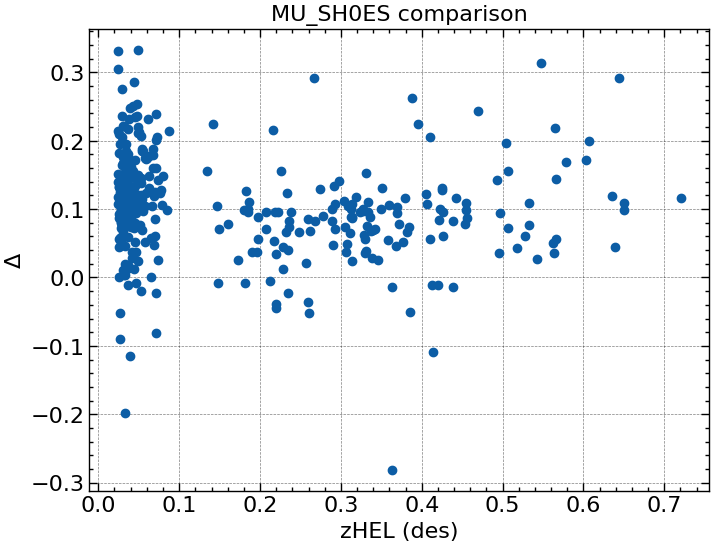

RA


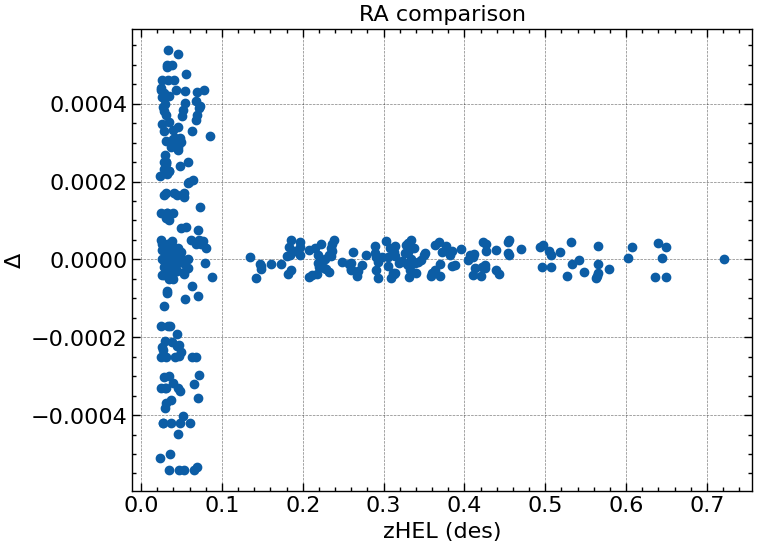

DEC


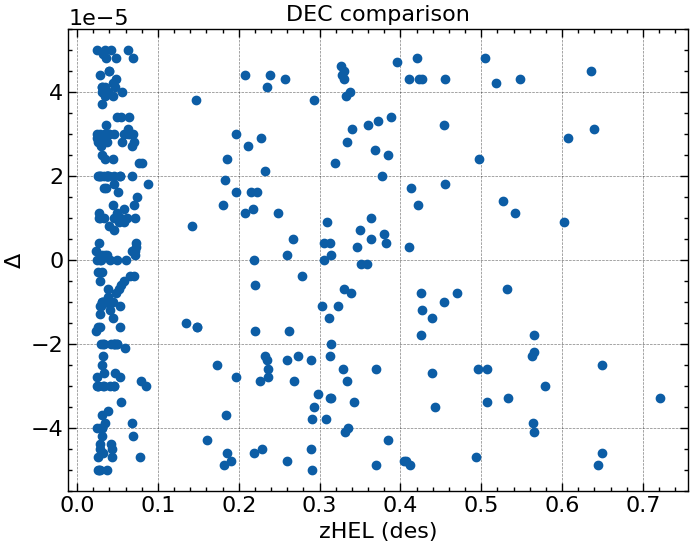

zHEL


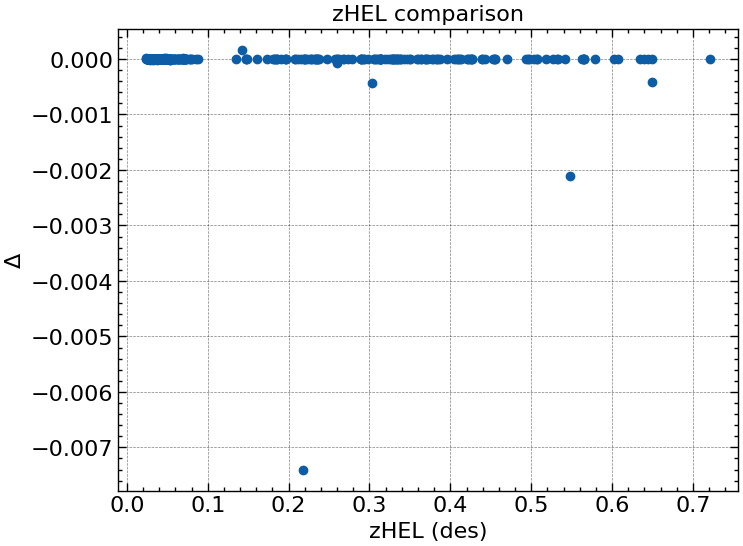

zHD


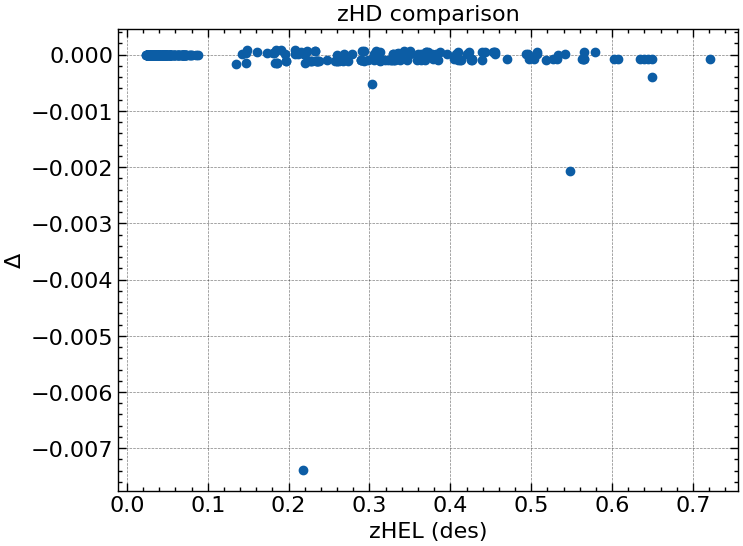

VPEC


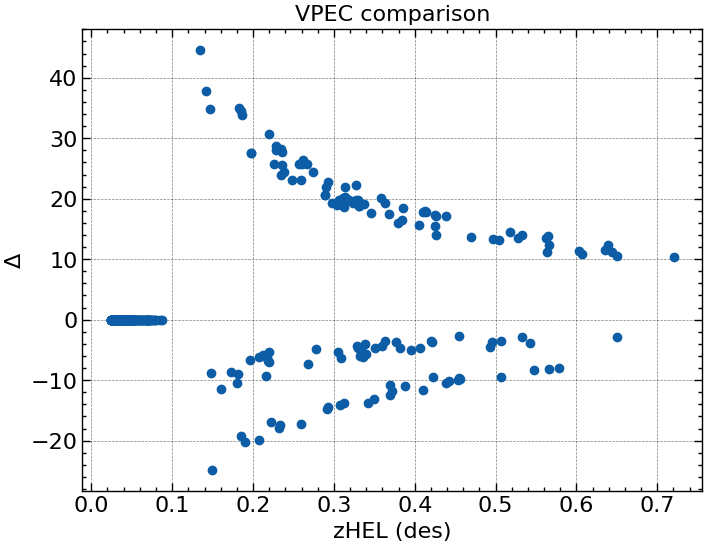

mB


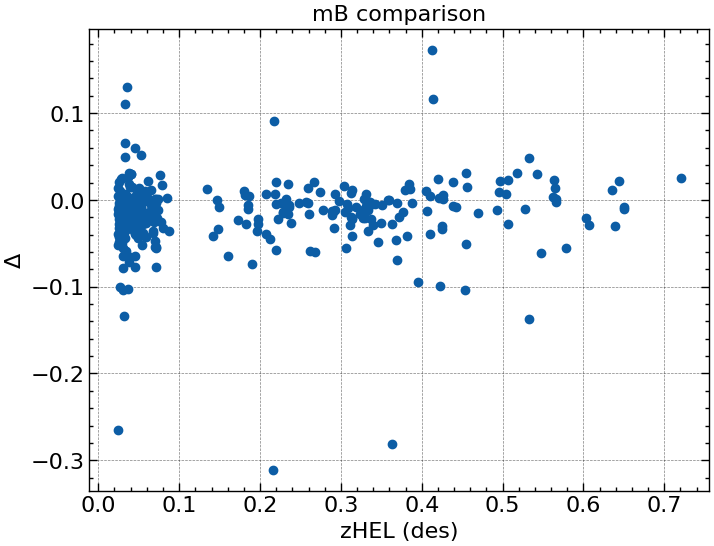

x1


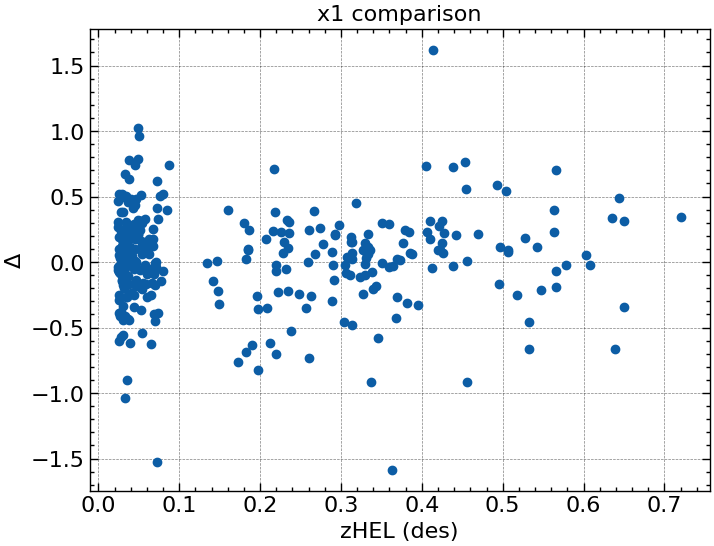

c


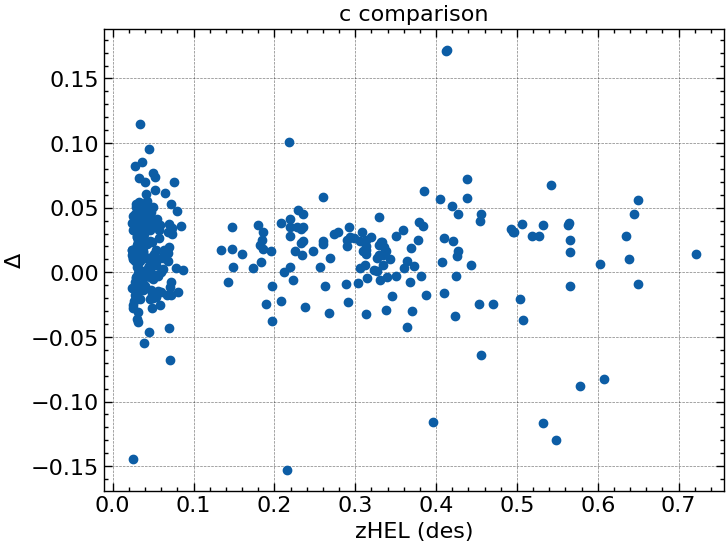

PKMJD


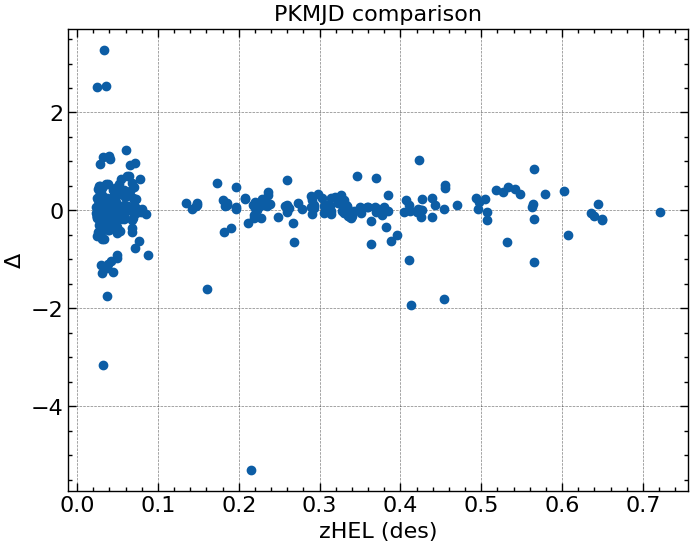

In [ ]:
for col in cols_map:
    print(col)
    x = matched[f'{col}_pplus']
    y = matched[f'{cols_map[col]}_des']
    diff = y - x

    plt.plot(matched['zHEL_des'], diff, 'o')

    # keep your existing plt.title/xlabel/ylabel applied to scatter
    plt.title(f'{col} comparison')
    plt.xlabel(f'zHEL (des)')
    plt.ylabel(f'$\Delta$')
    plt.show()


MU_SH0ES


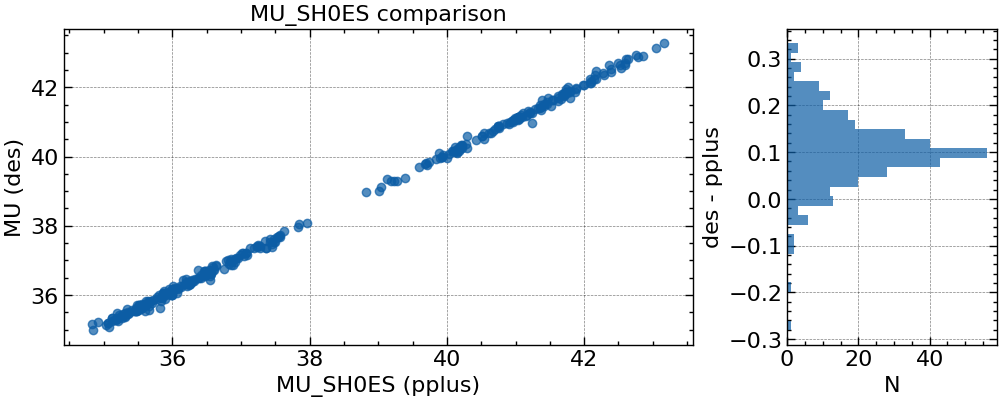

RA


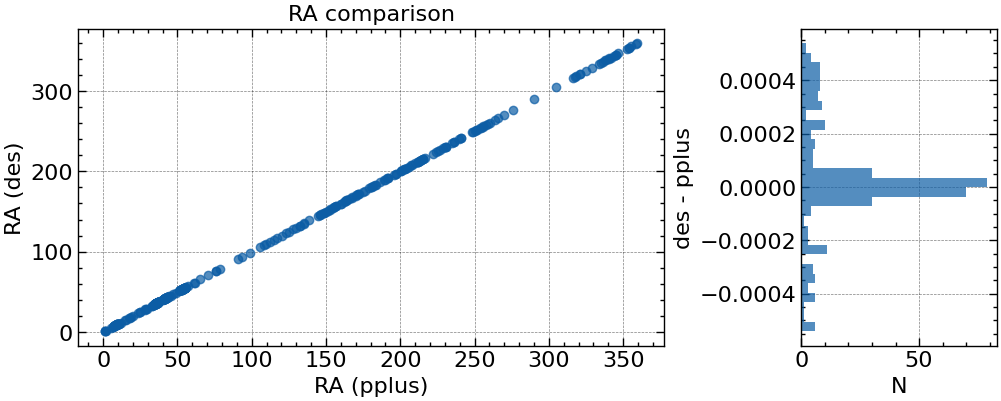

DEC


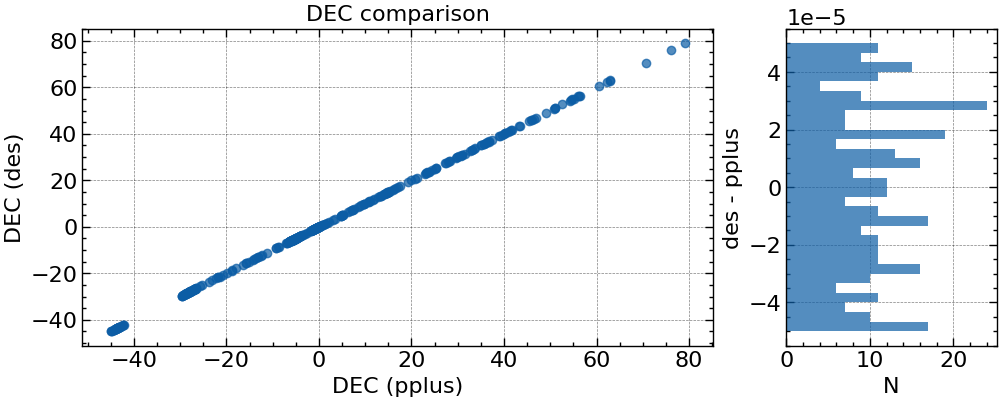

zHEL


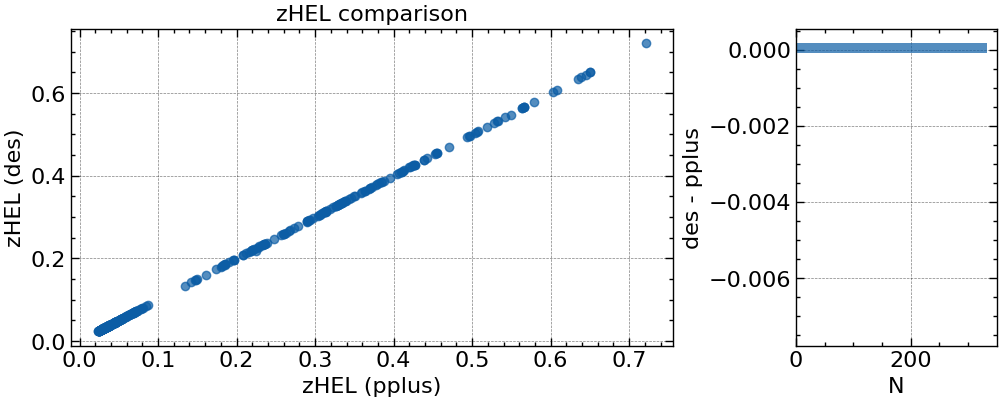

zHD


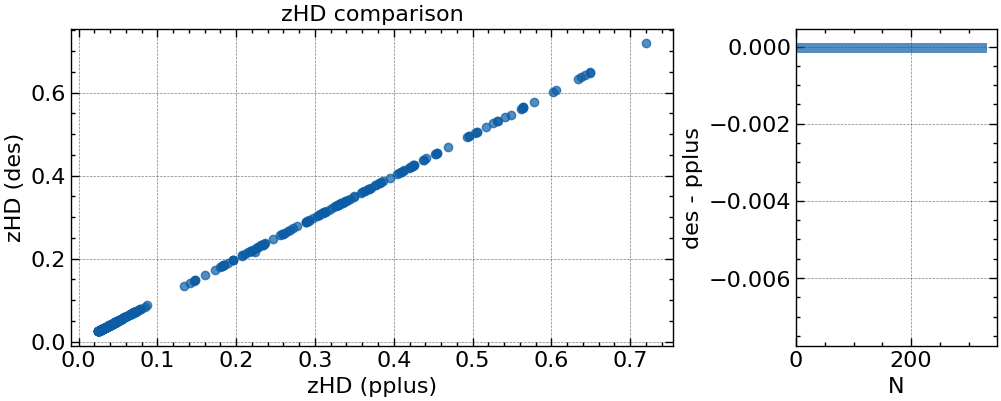

VPEC


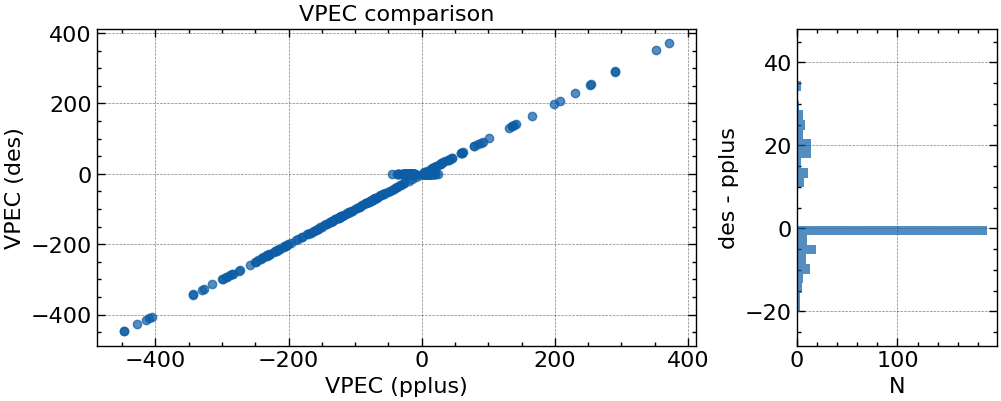

mB


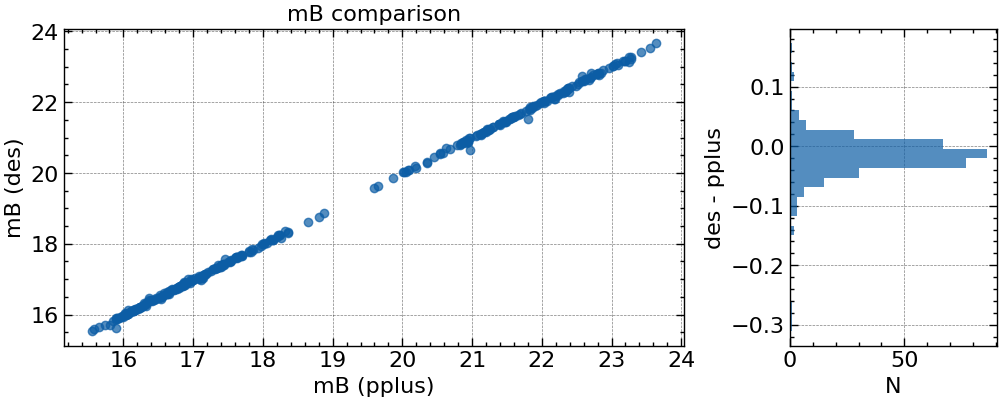

x1


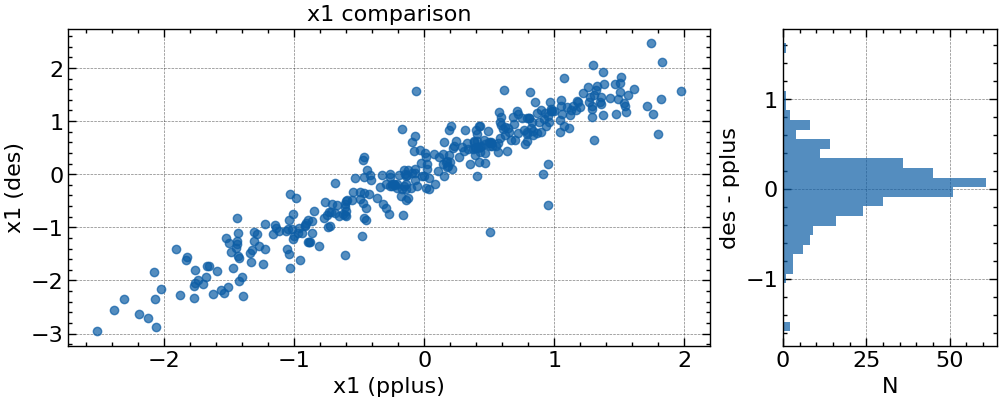

c


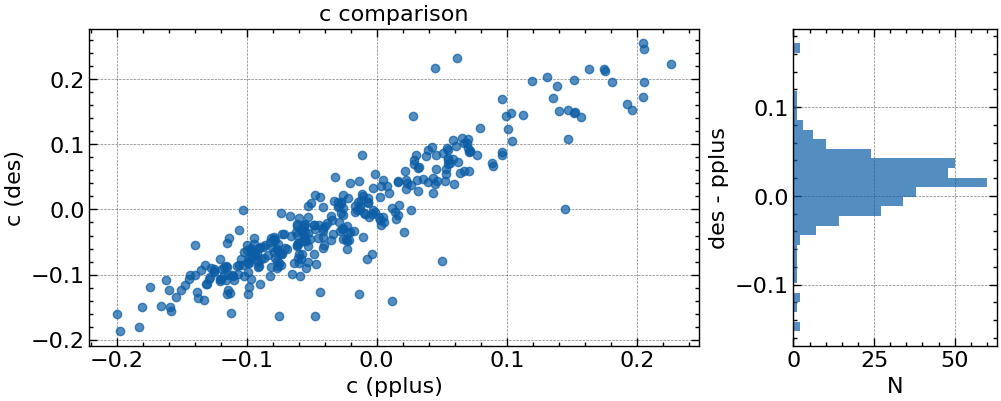

PKMJD


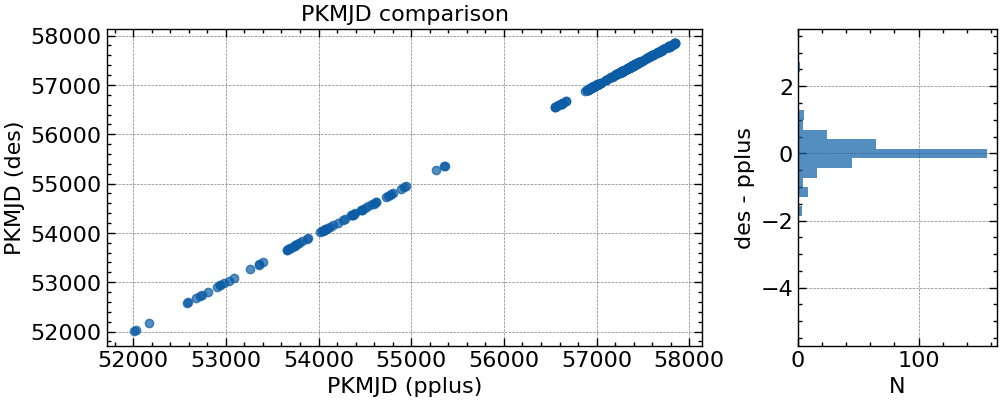

In [ ]:
for col in cols_map:
    print(col)
    x = matched[f'{col}_pplus']
    y = matched[f'{cols_map[col]}_des']
    diff = y - x

    fig, (ax_scatter, ax_hist) = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={'width_ratios': [3, 1]},
        constrained_layout=True
    )

    ax_scatter.plot(x, y, 'o', alpha=0.7)

    # side histogram of (des - pplus)
    ax_hist.hist(diff.dropna(), bins=30, orientation='horizontal', alpha=0.7)
    ax_hist.set_xlabel('N')
    ax_hist.set_ylabel('des - pplus')

    # keep your existing plt.title/xlabel/ylabel applied to scatter
    plt.sca(ax_scatter)
    plt.title(f'{col} comparison')
    plt.xlabel(f'{col} (pplus)')
    plt.ylabel(f'{cols_map[col]} (des)')
    plt.show()

(array([ 1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  3.,
         3.,  6., 15., 30., 77., 86., 67., 28.,  7.,  4.,  1.,  1.,  0.,
         2.,  1.,  0.,  1.]),
 array([-0.3107    , -0.29457167, -0.27844333, -0.262315  , -0.24618667,
        -0.23005833, -0.21393   , -0.19780167, -0.18167333, -0.165545  ,
        -0.14941667, -0.13328833, -0.11716   , -0.10103167, -0.08490333,
        -0.068775  , -0.05264667, -0.03651833, -0.02039   , -0.00426167,
         0.01186667,  0.027995  ,  0.04412333,  0.06025167,  0.07638   ,
         0.09250833,  0.10863667,  0.124765  ,  0.14089333,  0.15702167,
         0.17315   ]),
 <BarContainer object of 30 artists>)

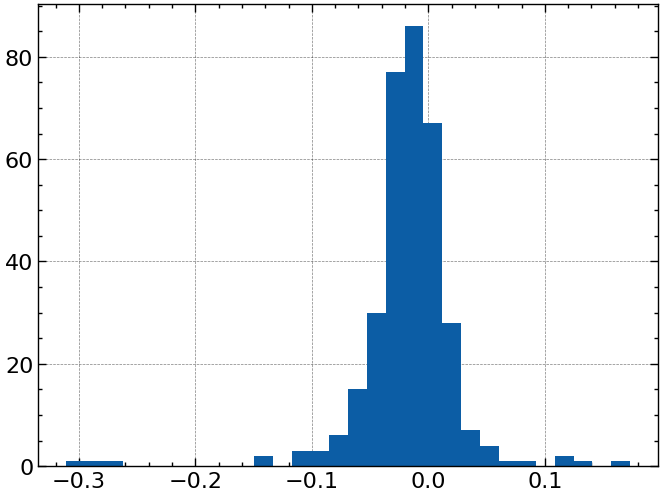

In [ ]:
plt.hist(matched['mB_des'] - matched['mB_pplus'],bins=30)

In [ ]:
results = []

for col1, col2 in cols_map.items():

    diff = des_sn5yr_common[col2].values - pplus_common[col1].values

    results.append({
        'quantity': col1,
        'mean_abs_diff': np.mean(np.abs(diff)),
        'max_abs_diff': np.max(np.abs(diff)),
        'std_diff': np.std(diff),
        'num_large_changes': np.sum(np.abs(diff) > 1e-3)
    })

summary = pd.DataFrame(results)

print(summary)

NameError: name 'cols_map' is not defined

In [ ]:
pplus_common[['RA','DEC','zHEL','zHD','MU_SH0ES','VPEC','mB','x1','c']]
des_sn5yr_common[['RA','DEC','zHEL','zHD','MU','VPEC','mB','x1','c']]

,RA,DEC,zHEL,zHD,MU_SH0ES,VPEC,mB,x1,c
0,53.6462,-28.1270,0.35067,0.35015,41.1867,4.7492,21.5389,0.899710,-0.118885
1,55.2180,-29.4000,0.21552,0.21507,39.8825,9.2775,20.9666,-2.074490,0.011385
2,43.1937,-0.1275,0.18299,0.18231,39.6885,-34.9294,20.0536,0.961400,-0.110221
3,7.4651,-43.1378,0.45440,0.45328,41.7953,9.6902,22.4364,1.373540,0.004591
4,54.6293,-27.0428,0.19599,0.19553,39.7111,6.7068,20.3543,-0.740056,-0.099286
...,...,...,...,...,...,...,...,...,...
373,132.4800,56.0990,0.04000,0.04095,36.4104,-143.5610,16.9721,0.711950,-0.047302
374,211.9690,9.6420,0.05440,0.05502,36.6433,78.2932,17.1232,0.753230,-0.060611
375,196.9140,6.3376,0.02385,0.02557,35.0621,-189.3220,15.6562,0.624390,-0.027287
376,214.1290,39.5864,0.02561,0.02598,35.3111,59.0114,16.0258,-0.158018,-0.027296


In [ ]:
des_sn5yr_common[['RA','DEC','zHEL','zHD','MU','VPEC','mB','x1','c']]

NameError: name 'des_sn5yr_common' is not defined

In [ ]:
des_sn5yr.to_csv('des_sn5yr.csv', index=False,sep=' ')

In [ ]:
des_meta

,CID,VARNAMES:,CIDint,IDSURVEY,TYPE,FIELD,CUTFLAG_SNANA,ERRFLAG_FIT,zHEL,zHELERR,...,M0DIFERR,CHI2_BEAMS,PROBCC_BEAMS,biasCor_nevt,biasCor_mu,biasCorErr_mu,biasCor_muCOVSCALE,biasCor_muCOVADD,IDSAMPLE,IZBIN
0,Gaia16agf,SN:,152,150,1,VOID,3,0,0.02507,0.00002,...,0.0105,0.35,0.000000,570,-0.0118,0.012,1.000,0.0222,1,0
1,2003it,SN:,181,63,1,VOID,3,0,0.02528,0.00001,...,0.0105,1.05,0.000000,1407,-0.0957,0.007,1.000,0.0104,0,0
2,2007cq,SN:,150,64,1,VOID,3,0,0.02604,0.00008,...,0.0105,3.46,0.000000,1343,-0.0262,0.007,1.000,0.0096,0,0
3,AT2017cfc,SN:,2,150,1,VOID,3,0,0.02403,0.00016,...,0.0105,0.21,0.000000,3492,-0.0846,0.004,1.000,0.0050,1,0
4,2007sw,SN:,109,65,1,VOID,3,0,0.02428,0.00006,...,0.0105,0.08,0.000000,1042,-0.0926,0.009,1.000,0.0157,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,1263785,SN:,1263785,10,0,C2+C3,3,0,1.06498,0.00100,...,0.0451,0.05,0.002351,815,0.5486,0.019,0.166,0.0000,3,19
1816,1842087,SN:,1842087,10,0,C3,3,0,1.08430,0.00100,...,0.0451,3.86,0.002113,71,0.0135,0.030,0.145,0.0000,3,19
1817,1339609,SN:,1339609,10,0,C2+C3,3,0,1.12212,0.00100,...,0.0451,0.50,0.011420,376,0.0680,0.021,0.149,0.0000,3,19
1818,1446080,SN:,1446080,10,0,C3,3,0,1.13140,0.00100,...,0.0451,1.53,0.000548,654,0.0940,0.017,0.156,0.0000,3,19


In [ ]:
plt.figure(figsize=(10,7))
bins = np.linspace(des5yr['zHEL'].min(), des5yr['zHEL'].max(), 50)
plt.hist(des5yr['zHEL'], bins=bins, alpha=0.7, color='blue',edgecolor='black',label='DES-SN5YR')
plt.hist(pplus['zHEL'], bins=bins, alpha=0.9, color='orange',lw=3,edgecolor='red', histtype='step',label='Pantheon+')
plt.xlabel('zHEL')
plt.ylabel('Frequency')
plt.title('Distribution of zHEL')
plt.legend()
plt.show()

NameError: name 'des5yr' is not defined

<Figure size 1000x700 with 0 Axes>

In [5]:

plt.rcParams['figure.figsize'] = [9, 6]
plt.rcParams['figure.dpi'] = 80
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

def plot_oneset(ax, RA, Dec, org=0, title='Mollweide projection', projection='mollweide', color=None, size=2.0, marker='o', fillstyle='full', globalparam=1, line=False, alpha=0.8, l1='Marker', ar='None', cmmap=False, vmin=None, vmax=None, val=None, edgecolors=None, ls='-', fill=False,label='Peculliar velocity'):
    x = np.remainder(RA + 360 - org, 360)  # shift RA values
    ind = x > 180
    x[ind] -= 360  # scale conversion to [-180, 180]
    x = -x  # reverse the scale: East to the left

    segments = []
    current_segment = []
    for xi, di in zip(x, Dec):
        if current_segment and abs(xi - current_segment[-1][0]) > 180:
            segments.append(current_segment)
            current_segment = []
        current_segment.append((xi, di))
    if current_segment:
        segments.append(current_segment)
    i=0
    for segment in segments:
        seg_x, seg_dec = zip(*segment)
        if not line:
            if cmmap:
                sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), c=val, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1)
                ax.set_xlabel('l', fontsize=20)
                ax.set_ylabel('b', fontsize=20)
                colorbar = plt.colorbar(sc, shrink=0.5)
                colorbar.set_label(label)
                colorbar.ax.yaxis.label.set_size(25)  # Adjust the font size as desired
            else:
                sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)
                ax.set_xlabel('$l$', fontsize=29)
                ax.set_ylabel('$b$', fontsize=29)
        else:
            if i==0:
                ax.plot(np.radians(seg_x), np.radians(seg_dec), alpha=0.8, color=color, lw=2, ls=ls, label=l1)
            else:
                ax.plot(np.radians(seg_x), np.radians(seg_dec), alpha=0.8, color=color, lw=2, ls=ls)
            i+=1

In [13]:
pplus_coords = SkyCoord(ra=pplus['RA'].values * u.deg,
                        dec=pplus['DEC'].values * u.deg,
                        frame='icrs')
pplus['l'] = pplus_coords.galactic.l.wrap_at(180 * u.deg).deg
pplus['b'] = pplus_coords.galactic.b.deg
vcmb=369.82 #km/s
c=299792.458
racmb=167.942
deccmb=-6.944
gal_cmb =SkyCoord(ra=racmb* u.deg, dec=deccmb* u.deg, frame='icrs').galactic


/tmp/ipykernel_1470907/1587197859.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)


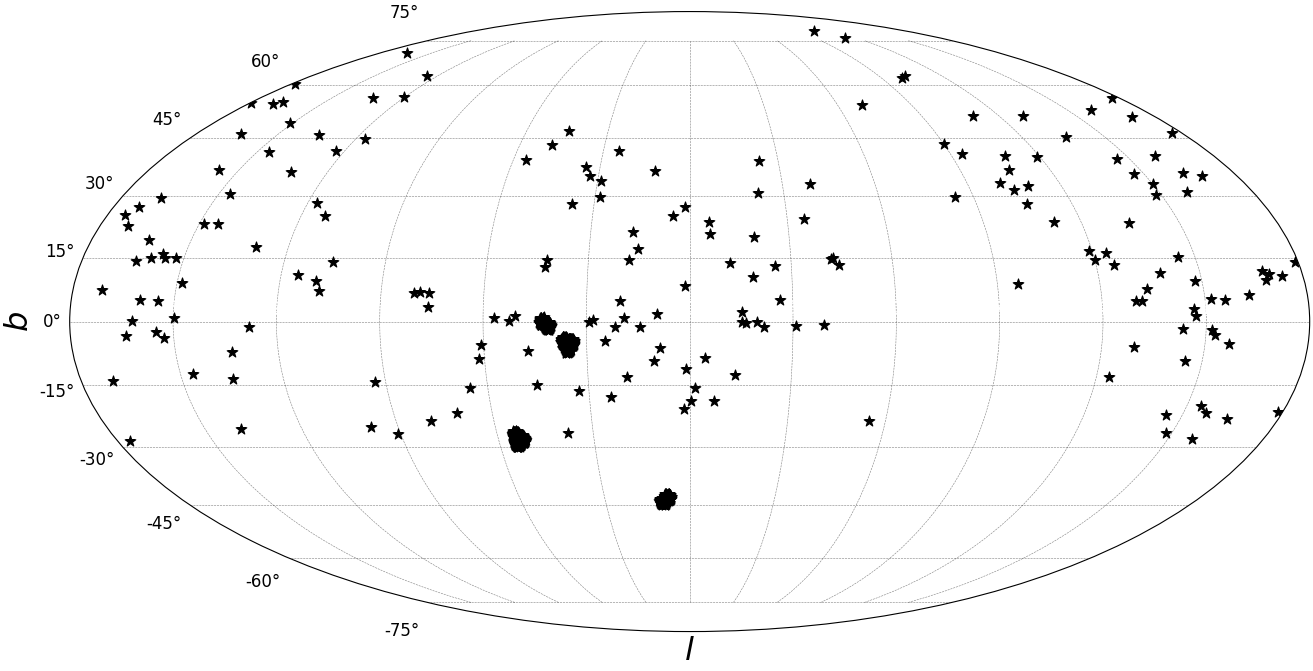

In [14]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)
plot_oneset(ax, des_m['RA'], des_m['DEC'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)


/tmp/ipykernel_1470907/1587197859.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)


Text(0.5, 1.0, 'DES-SN5YR (zHEL<0.09): 199 SNe Ia')

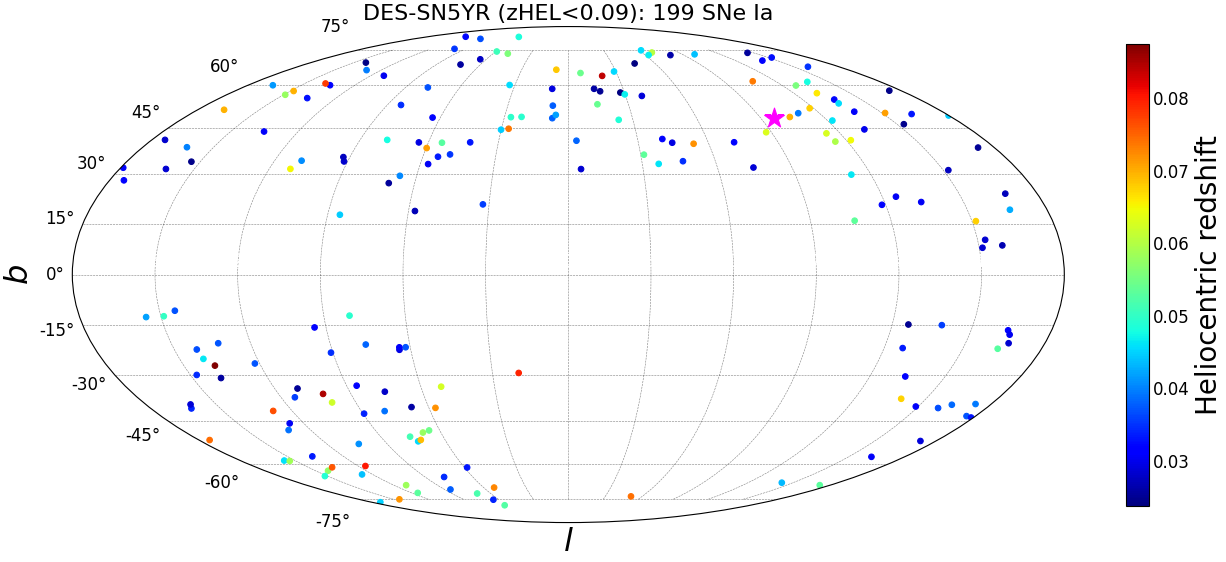

In [15]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)
subdata = des_m[des_m['zHEL']<0.09]

plot_oneset(ax, np.array([subdata['l']]), [subdata['b']], color='k', marker='.', size=100, fillstyle='none', line=False, alpha=1, l1=0,cmmap=True, val=np.array(subdata['zHEL']),label='Heliocentric redshift')
plot_oneset(ax, np.array([gal_cmb.l.value]), [gal_cmb.b.value], color='magenta', marker='*', size=350, fillstyle='none', line=False, alpha=1, l1=0, label='CMB dipole direction')

plt.title(f'DES-SN5YR (zHEL<0.09): {len(subdata)} SNe Ia', fontsize=20)

/tmp/ipykernel_1470907/1587197859.py:33: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(np.radians(seg_x), np.radians(seg_dec), color=color, alpha=alpha, cmap='jet', s=size, marker=marker, label=l1, vmin=vmin, vmax=vmax, edgecolors=edgecolors)


Text(0.5, 1.0, 'DES-SN5YR (zHEL<0.09): 1621 SNe Ia')

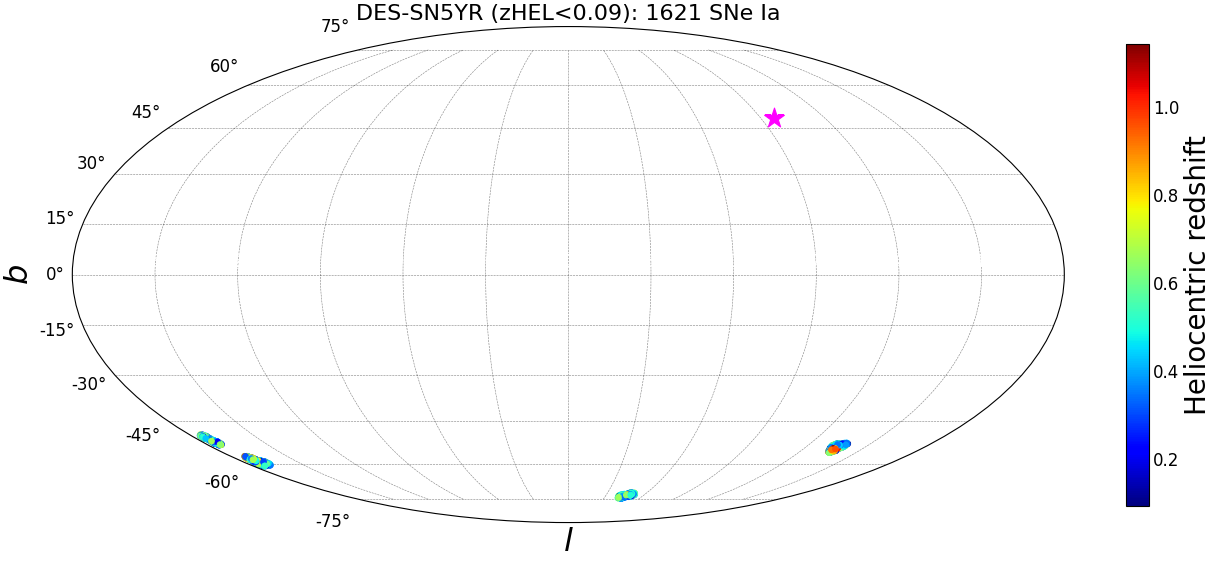

In [16]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)
subdata = des_m[des_m['zHEL']>0.09]

plot_oneset(ax, np.array([subdata['l']]), [subdata['b']], color='k', marker='.', size=100, fillstyle='none', line=False, alpha=1, l1=0,cmmap=True, val=np.array(subdata['zHEL']),label='Heliocentric redshift')
plot_oneset(ax, np.array([gal_cmb.l.value]), [gal_cmb.b.value], color='magenta', marker='*', size=350, fillstyle='none', line=False, alpha=1, l1=0, label='CMB dipole direction')

plt.title(f'DES-SN5YR (zHEL<0.09): {len(subdata)} SNe Ia', fontsize=20)

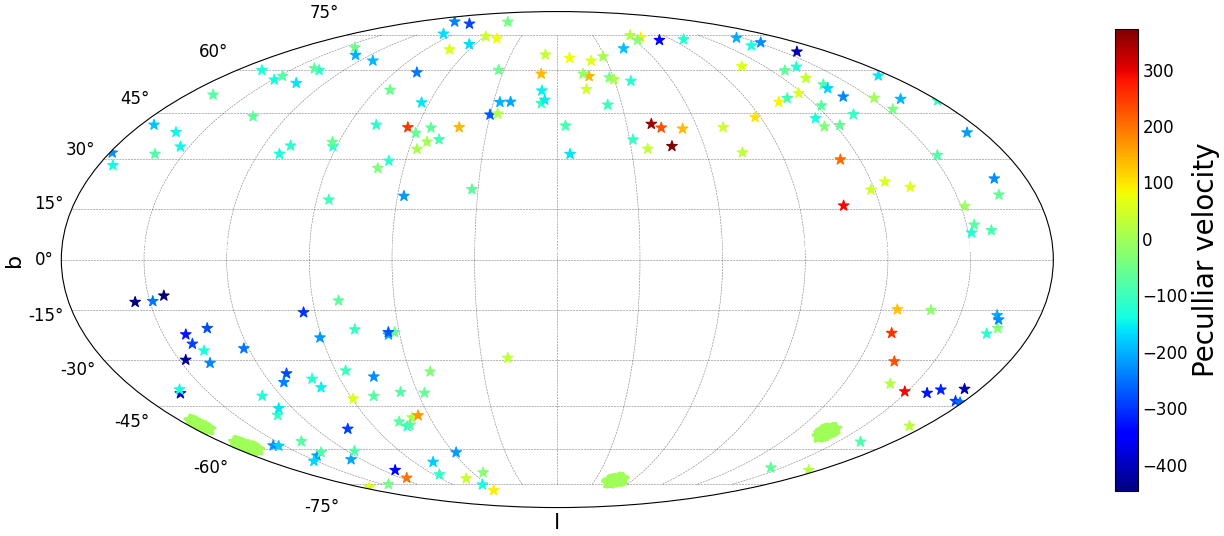

In [17]:
dict2={}
dict1={}

org = 0
tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])

tick_labels = np.remainder(tick_labels+360+org,360)

fig = plt.figure(figsize=(20, 15))
#ax.plot(galpan.l.wrap_at('180d').radian, galpan.b.radian,"gv",ms=10,label='PAN+ (JLA $\cap$ PAN+)')

ax = fig.add_subplot(111, projection='mollweide')
ax.set_xticklabels(tick_labels)

ax.tick_params(axis='x', colors='white')

#plot_oneset(ax, pplus['l'], pplus['b'], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0)
plot_oneset(ax, np.array([des_m['l']]), [des_m['b']], color='k', marker='*', size=100, fillstyle='none', line=False, alpha=1, l1=0,cmmap=True, val=np.array(des_m['VPEC']))


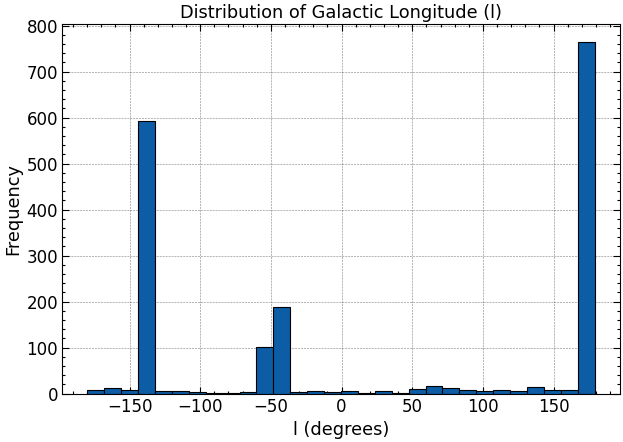

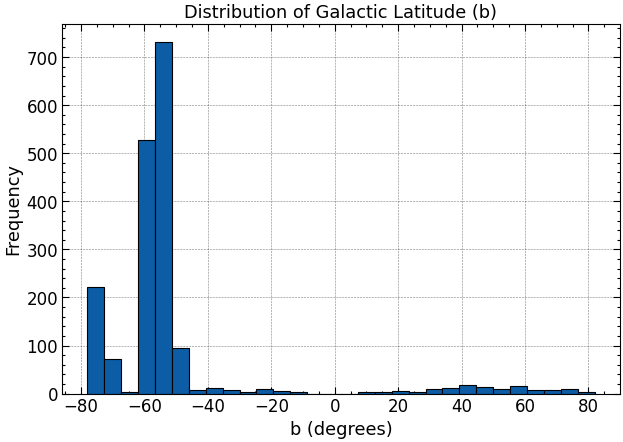

In [18]:
plt.hist(des_m['l'], bins=30, edgecolor='black')

plt.xlabel('l (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Galactic Longitude (l)')
plt.grid(True)
plt.show()
plt.hist(des_m['b'], bins=30, edgecolor='black')
plt.xlabel('b (degrees)')
plt.ylabel('Frequency')
plt.title('Distribution of Galactic Latitude (b)')
plt.grid(True)

In [ ]:
des_m

,VARNAMES:,CID,CIDint,IDSURVEY,TYPE,FIELD,CUTFLAG_SNANA,ERRFLAG_FIT,zHEL,zHELERR,...,biasCor_muCOVSCALE,biasCor_muCOVADD,IDSAMPLE,IZBIN,SNID,RA,DEC,REDSHIFT_HELIO,l,b
0,SN:,2004ef,0,64,1,VOID,3,0,0.03101,0.00002,...,1.000,0.0129,0,0,2004ef,340.541750,19.994560,0.031010,85.921335,-33.427164
1,SN:,2007nq,2,65,1,VOID,3,0,0.04389,0.00006,...,1.000,0.0033,0,0,2007nq,14.389870,-1.388610,0.043891,126.451314,-64.218518
2,SN:,2006az,5,64,1,VOID,3,0,0.03103,0.00001,...,1.000,0.0032,0,0,2006az,183.061170,56.179390,0.031029,133.888217,60.107359
3,SN:,2007is,6,65,1,VOID,3,0,0.02953,0.00001,...,1.000,0.0059,0,0,2007is,251.810790,40.243580,0.029526,64.093966,40.162656
4,SN:,2008gb,7,65,1,VOID,3,0,0.03700,0.00009,...,1.000,0.0069,0,0,2008gb,44.488040,46.865720,0.037001,144.331358,-10.681899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,SN:,1251536,1251536,10,0,X2,3,0,0.52851,0.00100,...,0.551,0.0000,4,14,1251536,34.971920,-6.933254,0.528510,173.078564,-60.872710
1816,SN:,1252939,1252939,10,0,X3,3,0,0.66800,0.00100,...,1.000,0.0058,2,15,1252939,36.183205,-4.845101,0.668000,172.005453,-58.523406
1817,SN:,1255423,1255423,10,0,S2,3,0,0.66801,0.00100,...,0.280,0.0000,5,15,1255423,41.982647,-1.019759,0.668010,174.767695,-51.763600
1818,SN:,1249304,1249304,10,0,S2,3,0,0.63802,0.00100,...,0.346,0.0000,5,15,1249304,40.629578,-1.440712,0.638020,173.652053,-53.006012


In [ ]:
JL

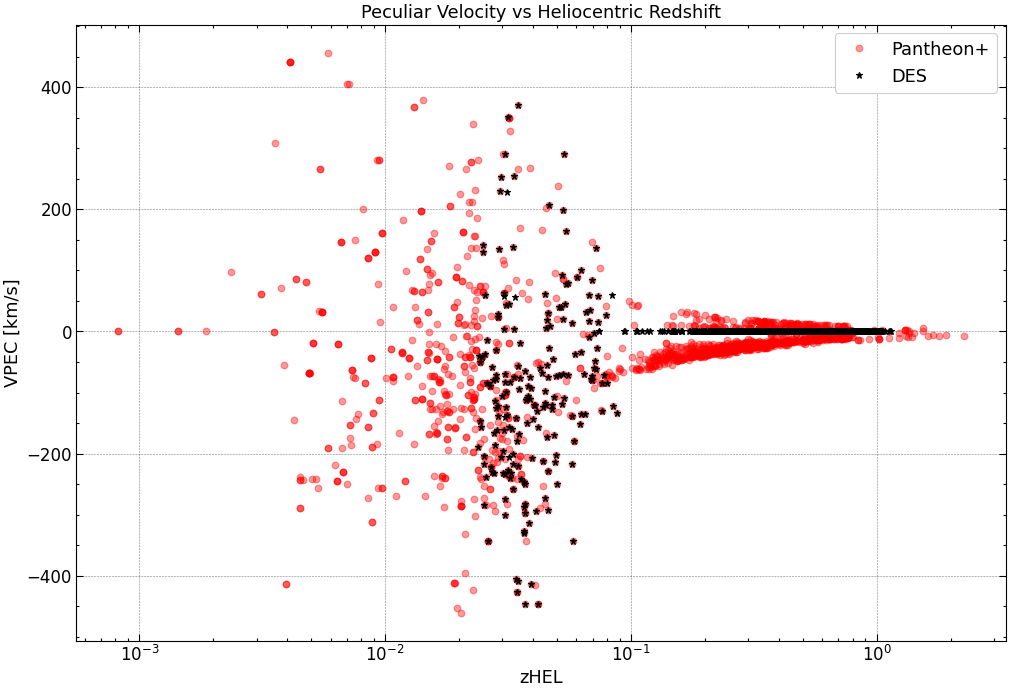

In [ ]:
plt.figure(figsize=(15, 10))
plt.plot(pplus['zHEL'], pplus['VPEC'], 'o', color='r',alpha=0.4,label='Pantheon+')
plt.plot(des_m['zHEL'], des_m['VPEC'], '*', label='DES',color='k')
plt.xlabel('zHEL')
plt.ylabel('VPEC [km/s]')
plt.xscale('log')
plt.title('Peculiar Velocity vs Heliocentric Redshift')
plt.legend()



In [45]:
pplus_coords = SkyCoord(ra=pplus['RA'].values * u.deg,
                        dec=pplus['DEC'].values * u.deg,
                        frame='icrs')
pplus['l'] = pplus_coords.galactic.l.value
pplus['b'] = pplus_coords.galactic.b.value   

In [ ]:
gal

In [20]:

def cos_angle(l,b,lref = gal_cmb.l, bref = gal_cmb.b):
    l_rad = np.radians(np.array(l))
    b_rad = np.radians(np.array(b))
    lref_rad = np.radians(np.array(lref))
    bref_rad = np.radians(np.array(bref))

    cos_angle = np.cos(ang(l_rad, b_rad, lref_rad, bref_rad))
    
    
    return cos_angle

In [ ]:
from scipy.optimize import curve_fit

In [19]:
from scipy.optimize import least_squares
import numpy as np
import astropy.units as u

c = 299792.458

def model_vpec(df, vcmb, lcmb, bcmb):

    zd = (
        np.sqrt(
            (1 - vcmb * cos_angle(
                df["l"] * u.deg,
                df["b"] * u.deg,
                lcmb * u.deg,
                bcmb * u.deg
            ) / c)
            /
            (1 + vcmb * cos_angle(
                df["l"] * u.deg,
                df["b"] * u.deg,
                lcmb * u.deg,
                bcmb * u.deg
            ) / c)
        )
        - 1
    )

    return c * (
        (1 + df["zHEL"])
        - (1 + df["zHD"]) * (1 + zd)
    )

def residuals(pars, df):

    vcmb, lcmb, bcmb = pars

    vpec_model = model_vpec(df, vcmb, lcmb, bcmb)

    return vpec_model - df["VPEC"].values
x0 = [370, 264, 48]  # Planck/COBE-ish starting point

res = least_squares(
    residuals,
    x0,
    args=(des_sorted,),
    bounds=(
        [0,   0, -90],
        [1000, 360, 90]
    )
)

vcmb_fit, lcmb_fit, bcmb_fit = res.x

print("vcmb =", vcmb_fit)
print("l    =", lcmb_fit)
print("b    =", bcmb_fit)

NameError: name 'des_sorted' is not defined

In [10]:
def cos_angle(l,b,lref = gal_cmb.l, bref = gal_cmb.b):
    l_rad = np.radians(np.array(l))
    b_rad = np.radians(np.array(b))
    lref_rad = np.radians(np.array(lref))
    bref_rad = np.radians(np.array(bref))

    cos_angle = np.cos(ang(l_rad, b_rad, lref_rad, bref_rad))
    
    
    return cos_angle
def estimate_vpec(df, vcmb=369.82, c=299792.458, galcmb=gal_cmb.l, deccmb=gal_cmb.b):
    zd = np.sqrt((1 - vcmb * cos_angle(df['l'] * u.deg, df['b'] * u.deg,) / c) / (1 + vcmb * cos_angle(df['l'] * u.deg, df['b'] * u.deg) / c)) - 1
    vpec = ((1 + df['zHEL']) - (1 + df['zHD']) * (1 + zd)) * c
    return vpec

des_sorted = des_m.sort_values(by='zHEL')
hel_vals = des_sorted['zHEL']
hd_vals = des_sorted['zHD']
vpec_vals = des_sorted['VPEC']

# popt,pcov = curve_fit(estimate_vpec,)

NameError: name 'gal_cmb' is not defined

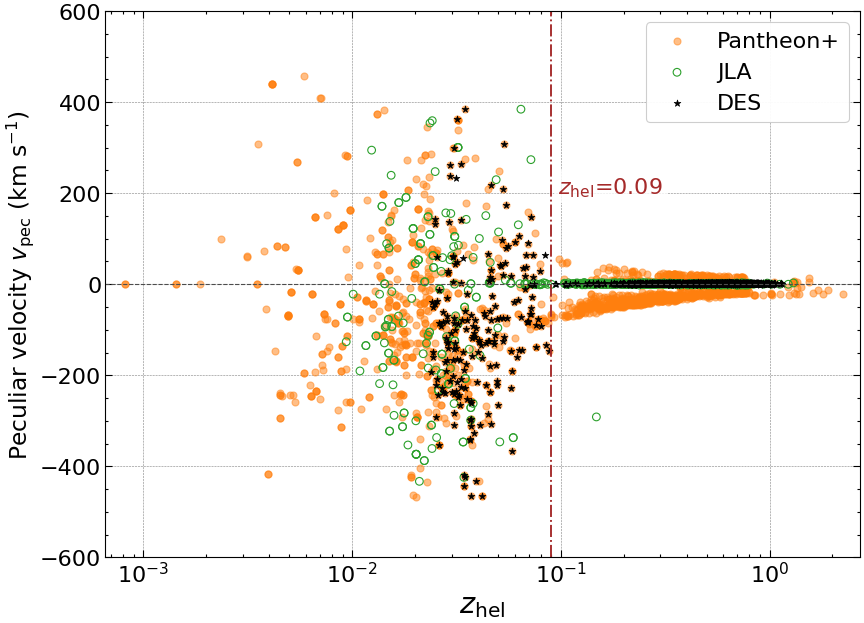

In [51]:
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

fig, ax = plt.subplots(figsize=(11,8))


zd=np.sqrt((1-vcmb*cos_angle(des_m['l']*u.deg, des_m['b']*u.deg)/c)/(1+vcmb*cos_angle(des_m['l']*u.deg, des_m['b']*u.deg)/c))-1
v = ((1+des_m['zHEL'])-(1+des_m['zHD'])*(1+zd))*c
zd_pan = np.sqrt((1-vcmb*cos_angle(pplus['l']*u.deg, pplus['b']*u.deg)/c)/(1+vcmb*cos_angle(pplus['l']*u.deg, pplus['b']*u.deg)/c))-1
v_pan = ((1+pplus['zHEL'])-(1+pplus['zHD'])*(1+zd_pan))*c
zd_jla = np.sqrt((1-vcmb*cos_angle(JLA['l']*u.deg, JLA['b']*u.deg)/c)/(1+vcmb*cos_angle(JLA['l']*u.deg, JLA['b']*u.deg)/c))-1
v_jla = ((1+JLA['zhel'])-(1+JLA['zcmb'])*(1+zd_jla))*c   

ax.scatter(pplus['zHEL'], v_pan, s=40, c='tab:orange', alpha=0.50, label='Pantheon+')
ax.scatter(JLA['zhel'], v_jla, s=48, facecolors='none', edgecolors='tab:green', linewidths=1.0, label='JLA')
ax.scatter(des_m['zHEL'], v, s=40, marker='*', c='k', linewidths=0.6, label='DES')

ax.axhline(0, color='0.3', linestyle='--', linewidth=1)
ax.set_xscale('log')

z_all = np.concatenate([pplus['zHEL'].values, des_m['zHEL'].values, JLA['zhel'].values])
zpos = z_all[z_all > 0]
zmin = max(zpos.min() * 0.8, 1e-4)
zmax = max(z_all.max() * 1.2, 2.0)
ax.set_xlim(zmin, zmax)

ax.set_ylim(-600, 600)
ax.axvline(0.09, color='brown', linestyle='-.', linewidth=1.7)
ax.text(0.6, 0.7, '$z_{\\rm hel}$=0.09', transform=ax.transAxes, fontsize=20, color='brown', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.set_xlabel('$z_{\\rm hel}$', fontsize=26)
ax.set_ylabel('Peculiar velocity $v_{\\rm pec}$ (km s$^{-1}$)', fontsize=21)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.xaxis.set_major_locator(LogLocator(numticks=6))
ax.xaxis.set_major_formatter(LogFormatterSciNotation())

#ax.grid(True, which='both', linestyle=':', alpha=0.6)

leg = ax.legend(frameon=True, fontsize=20, loc='upper right')
leg.get_frame().set_alpha(0.95)

med = np.nanmedian(v)
std = np.nanstd(v)
# ax.text(0.02, 0.95, f'DES median = {med:.1f} km/s\nσ = {std:.1f} km/s',
#     transform=ax.transAxes, fontsize=11, va='top',
#     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.savefig('vpec_vs_zhel_publication.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [57]:
c/3e5

0.9993081933333333

In [65]:
mag_corr = abs((5/np.log(10))*370/(c*(0.01)))
mag_corr

0.26800033492537556

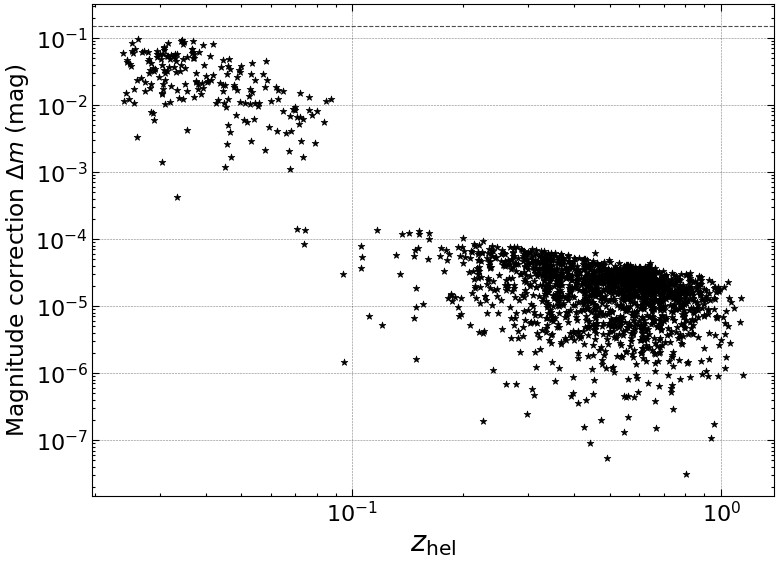

In [68]:
mag_corr = abs((5/np.log(10))*v/(c*(des_m['zHEL'])))
fig, ax = plt.subplots(figsize=(11,8))

mag_corr_pan = abs((5/np.log(10))*v_pan/(c*(pplus['zHEL'])))
#ax.scatter(pplus['zHEL'], mag_corr_pan, s=40, c='tab:orange', alpha=0.50, label='Pantheon+')
mag_corr_jla = abs((5/np.log(10))*v_jla/(c*(JLA['zhel'])))
#ax.scatter(JLA['zhel'], mag_corr_jla, s=48, facecolors='none', edgecolors='tab:green', linewidths=1.0, label='JLA')
ax.scatter(des_m['zHEL'], mag_corr, s=40, marker='*', c='k', linewidths=0.6, label='DES')

ax.axhline(0.15, color='0.3', linestyle='--', linewidth=1, label='Reported difference between high and \n low z SNe – evidence for acceleration')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Magnitude correction $\\Delta m$ (mag)', fontsize=21)
ax.set_xlabel('$z_{\\rm hel}$', fontsize=26)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.xaxis.set_major_locator(LogLocator(numticks=6))
ax.xaxis.set_major_formatter(LogFormatterSciNotation())

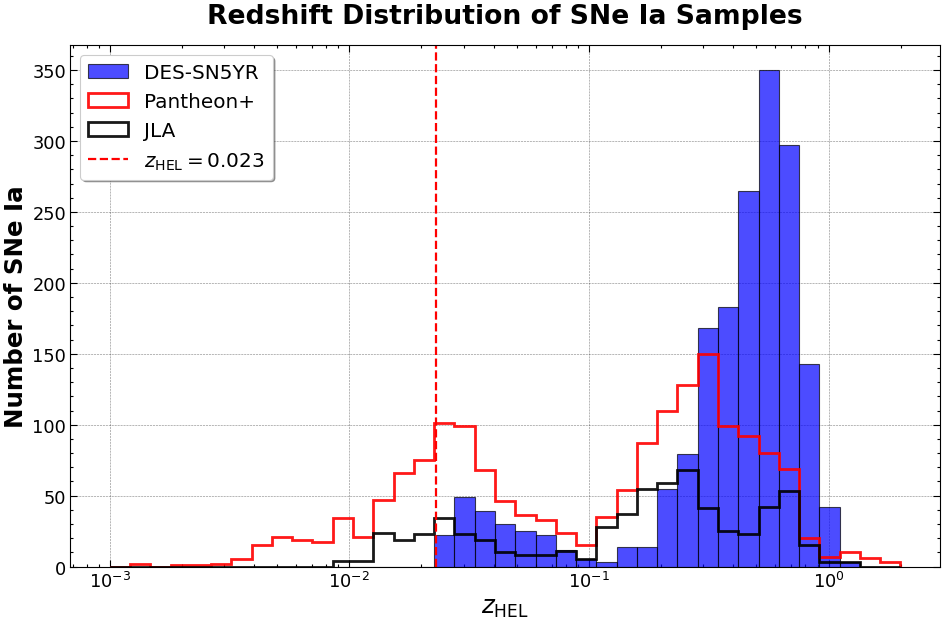

In [12]:
plt.figure(figsize=(12, 8))
bins = np.logspace(-3, 0.3, 40)

plt.hist(des_m['zHEL'], bins=bins, alpha=0.7, color='blue', edgecolor='black', label='DES-SN5YR')
plt.hist(pplus['zHEL'], bins=bins, alpha=0.9, color='orange', lw=2.5, edgecolor='red', histtype='step', label='Pantheon+')
plt.hist(JLA['zhel'], bins=bins, alpha=0.9, color='green', lw=2.5, edgecolor='black', histtype='step', label='JLA')

plt.axvline(0.023, color='red', linestyle='--', linewidth=2, label='$z_{\\rm HEL}=0.023$')

plt.xscale('log')
plt.xlabel('$z_{\\rm HEL}$', fontsize=22, fontweight='bold')
plt.ylabel('Number of SNe Ia', fontsize=22, fontweight='bold')
plt.title('Redshift Distribution of SNe Ia Samples', fontsize=24, fontweight='bold', pad=20)

plt.legend(fontsize=18, loc='best', frameon=True, fancybox=True, shadow=True)
plt.tick_params(axis='both', which='major', labelsize=16)
#plt.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig('zhel_distribution_publication.pdf', dpi=300, bbox_inches='tight')
plt.show()

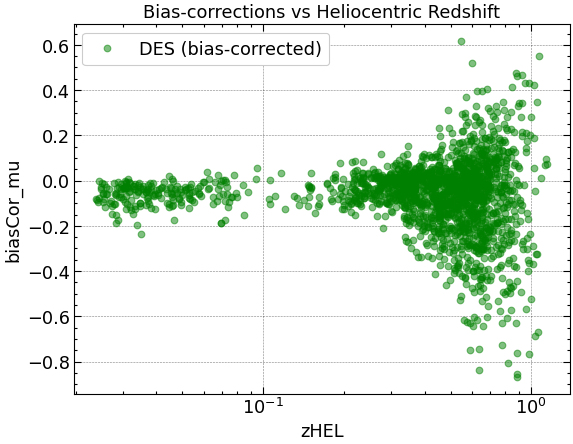

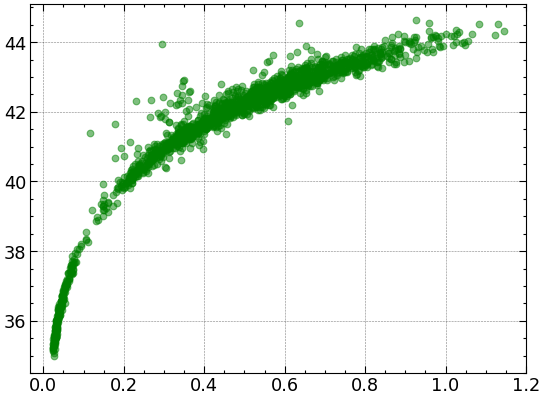

In [ ]:
plt.plot(des_m['zHEL'], des_m['biasCor_mu'], 'o', color='g', alpha=0.5, label='DES (bias-corrected)')
plt.xlabel('zHEL')
plt.ylabel('biasCor_mu')
plt.xscale('log')
plt.title('Bias-corrections vs Heliocentric Redshift')
plt.legend()
plt.show()

plt.plot(des_m['zHEL'], des_m['MU'], 'o', color='g', alpha=0.5, label='DES (bias-corrected)')

In [ ]:
des_m.columns

Index(['VARNAMES:', 'CID', 'CIDint', 'IDSURVEY', 'TYPE', 'FIELD',
       'CUTFLAG_SNANA', 'ERRFLAG_FIT', 'zHEL', 'zHELERR', 'zCMB', 'zCMBERR',
       'zHD', 'zHDERR', 'VPEC', 'VPECERR', 'LENSDMU', 'LENSDMUERR', 'MWEBV',
       'HOST_NMATCH', 'HOST_NMATCH2', 'HOST_OBJID', 'HOST_ZPHOT',
       'HOST_ZPHOTERR', 'HOST_ZSPEC', 'HOST_ZSPECERR', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'HOST_DDLR', 'HOST_CONFUSION', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'HOST_LOGSFR', 'HOST_LOGSFR_ERR', 'HOST_LOGsSFR',
       'HOST_LOGsSFR_ERR', 'HOST_COLOR', 'HOST_COLOR_ERR', 'HOST_MAG_g',
       'HOST_MAG_i', 'HOST_SBFLUXCAL_g', 'HOST_SBFLUXCAL_i', 'HOST_SBMAG_g',
       'HOST_SBMAG_i', 'PKMJDINI', 'SNRMAX1', 'SNRMAX2', 'SNRMAX3', 'SNRSUM',
       'BANDLIST', 'PKMJD', 'PKMJDERR', 'x1', 'x1ERR', 'c', 'cERR', 'mB',
       'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'NDOF',
       'FITCHI2', 'FITPROB', 'RADIUS_POP', 'PROB_SCONE', 'PROB_SNIRFV19',
       'PROB_SNNDESCC', 'PROB_SNNJ17',